# Condenser System Design Curves

Computes condenser spot-size design curves for the model TEM column.
Solves for CL1/CL3 focal lengths that image the virtual source onto the sample
with specified FWHM values, then writes the drive-current table to
`microscope.toml` → `[modes.illumination.parallel]`.


In [36]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.01"

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import brentq
import tomlkit

from optics_helpers import (
    build_chain, electron_wavelength,
    q_inv_from_source, propagate_q_inv, fwhm_from_q_inv,
    current_from_focal, focal_bounds_from_current_bounds, PX_TO_M,
)

%matplotlib widget
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# ── Load microscope.toml ──
toml_path = Path("microscope.toml")
cfg = tomlkit.parse(toml_path.read_text())
beam = cfg['beam']
lenses = cfg['lenses']

# ── CAD pixel landmarks → drift distances [m] ──
_y = {'Source': 250, 'CL1': 330, 'CL3': 369, 'Aperture': 373,
      'CorrTop': 385, 'CorrBot': 504, 'CMini': 529, 'OPL': 570}
_gap = lambda a, b: abs(_y[b] - _y[a]) * PX_TO_M

d_S_C1   = _gap('Source', 'CL1')
d_C1_C3  = _gap('CL1', 'CL3')
d_C3_A   = _gap('CL3', 'Aperture')
d_A_Cm   = _gap('Aperture', 'CorrTop') + _gap('CorrBot', 'CMini')
d_Cm_OPL = _gap('CMini', 'OPL')

f_Cm  = 5.0e-3   # C_mini fixed focal length [m]
f_OPL = 5.0e-3   # Obj_prefield fixed focal length [m]

# ── Source beam ──
V   = float(beam['voltage_kV']) * 1e3
lam = electron_wavelength(V)
q_src = q_inv_from_source(
    0.5 * float(beam['virtual_source_diameter_nm']) * 1e-9,
    float(beam['source_half_angle_mrad']) * 1e-3,
    lam,
)

# ── Lens current/focal conversion ──
Gc = {k: float(lenses[k]['Gc'])    for k in ('CL1', 'CL3')}
N  = {k: float(lenses[k]['turns']) for k in ('CL1', 'CL3')}
I_bnd = {'CL1': (0.4, 1.9), 'CL3': (0.4, 1.9)}
f_bnd = {k: focal_bounds_from_current_bounds(Gc[k], N[k], *I_bnd[k]) for k in Gc}

N_spots = 8
target_range_nm = (50, 1500.0)

print(f"Drifts [mm]: S→C1={d_S_C1*1e3:.1f}, C1→C3={d_C1_C3*1e3:.1f}, "
      f"C3→A={d_C3_A*1e3:.1f}, A→Cm={d_A_Cm*1e3:.1f}, Cm→OPL={d_Cm_OPL*1e3:.1f}")
print(f"λ = {lam*1e12:.2f} pm,  q_src⁻¹ = {q_src.real:.2e} + {q_src.imag:.2e}j")
print(f"f bounds [mm]: {', '.join(f'{k}: ({v[0]*1e3:.2f}, {v[1]*1e3:.2f})' for k, v in f_bnd.items())}")


Drifts [mm]: S→C1=166.7, C1→C3=81.2, C3→A=8.3, A→Cm=77.1, Cm→OPL=85.4
λ = 2.51 pm,  q_src⁻¹ = 6.02e+03 + 7.98e+03j
f bounds [mm]: CL1: (3.85, 86.81), CL3: (5.34, 120.56)


## Condenser Solver

The condenser chain is Source → CL1 → CL3 → C_mini → Obj_prefield → sample.
C_mini and Obj_prefield are at fixed focal lengths; only CL1 and CL3 vary.

**Key constraint:** $B = 0$ at the C_mini object plane (real image).
For the two-lens pre-system $P(d_1) \cdot L(f_1) \cdot P(d_2) \cdot L(f_3) \cdot P(d_3)$,
this yields a closed-form solution:

$$f_1 = \frac{d_1(d_2 \alpha + d_3)}{(d_1 + d_2)\alpha + d_3}, \qquad \alpha = 1 - d_3 / f_3$$

The FWHM at the sample is then computed via Gaussian beam (ABCD) propagation,
and $N$ spot sizes are found by root-finding on the FWHM curve.


In [37]:
# ── C_mini conjugate (thin lens equation) ──
d_img_cm = d_Cm_OPL - f_OPL                    # C_mini image distance
d_obj_cm = 1.0 / (1.0/f_Cm - 1.0/d_img_cm)    # C_mini object distance
d_c3_to_obj = (d_C3_A + d_A_Cm) - d_obj_cm     # CL3 → C_mini object plane

print(f"C_mini conjugate: obj = {d_obj_cm*1e3:.3f} mm, img = {d_img_cm*1e3:.3f} mm")

# ── Fixed post-optics matrix (C_mini + OPL → sample) ──
M_post = build_chain([
    ('P', d_obj_cm), ('L', f_Cm), ('P', d_img_cm),   # C_mini
    ('P', f_OPL), ('L', f_OPL), ('P', f_OPL),         # OPL → sample
])

# ── Closed-form f_CL1 from B = 0 constraint ──
d1, d2, d3 = d_S_C1, d_C1_C3, d_c3_to_obj

def f1_from_f3(f3):
    """Analytic f_CL1 that images source onto C_mini object plane."""
    alpha = 1.0 - d3 / f3
    return d1 * (d2 * alpha + d3) / ((d1 + d2) * alpha + d3)

def fwhm_at_f3(f3):
    """Sample-plane FWHM [nm] for given f_CL3."""
    f1 = f1_from_f3(f3)
    M_pre = build_chain([('P', d1), ('L', f1), ('P', d2), ('L', f3), ('P', d3)])
    q_out = propagate_q_inv(q_src, M_post @ M_pre)
    return fwhm_from_q_inv(q_out, lam) * 1e9

def is_feasible(f3):
    """Check focal lengths and currents are within bounds."""
    f1 = f1_from_f3(f3)
    if not (f_bnd['CL1'][0] <= f1 <= f_bnd['CL1'][1]):
        return False
    I1 = current_from_focal(f1, Gc['CL1'], N['CL1'])
    I3 = current_from_focal(f3, Gc['CL3'], N['CL3'])
    return (I_bnd['CL1'][0] <= I1 <= I_bnd['CL1'][1] and
            I_bnd['CL3'][0] <= I3 <= I_bnd['CL3'][1])

# ── Scan feasible FWHM range ──
f3_grid = np.geomspace(f_bnd['CL3'][0], f_bnd['CL3'][1], 2000)
ok = np.array([is_feasible(f3) for f3 in f3_grid])
fwhm_grid = np.array([fwhm_at_f3(f3) if ok[i] else np.nan
                       for i, f3 in enumerate(f3_grid)])

f3_ok = f3_grid[ok]
fwhm_ok = fwhm_grid[ok]
print(f"Feasible: {ok.sum()} points, FWHM range: {fwhm_ok.min():.0f} – {fwhm_ok.max():.0f} nm")

# ── Solve for N_spots geometrically-spaced targets ──
lo = max(target_range_nm[0], fwhm_ok.min())
hi = min(target_range_nm[1], fwhm_ok.max())
targets_nm = np.geomspace(lo, hi, N_spots)

def solve_f3_for_fwhm(target):
    """Find f_CL3 giving the target FWHM, using scan grid for bracketing."""
    for j in range(len(f3_ok) - 1):
        if (fwhm_ok[j] - target) * (fwhm_ok[j+1] - target) <= 0:
            return brentq(lambda x: fwhm_at_f3(x) - target, f3_ok[j], f3_ok[j+1])
    return f3_ok[np.argmin(np.abs(fwhm_ok - target))]

results = []
for target in targets_nm:
    f3 = solve_f3_for_fwhm(target)
    f1 = f1_from_f3(f3)
    results.append({
        'f_CL1': f1, 'f_CL3': f3,
        'I_CL1': current_from_focal(f1, Gc['CL1'], N['CL1']),
        'I_CL3': current_from_focal(f3, Gc['CL3'], N['CL3']),
        'fwhm_nm': fwhm_at_f3(f3),
    })

# Sort by CL1 focal length (descending) and number
results.sort(key=lambda r: r['f_CL1'], reverse=True)
for i, r in enumerate(results, 1):
    r['spot'] = i

for r in results:
    print(f"Spot {r['spot']}: FWHM = {r['fwhm_nm']:.0f} nm, "
          f"CL1 = {r['I_CL1']:.4f} A, CL3 = {r['I_CL3']:.4f} A, "
          f"f1 = {r['f_CL1']*1e3:.2f} mm, f3 = {r['f_CL3']*1e3:.2f} mm")


C_mini conjugate: obj = 5.331 mm, img = 80.417 mm
Feasible: 1281 points, FWHM range: 38 – 1542 nm
Spot 1: FWHM = 50 nm, CL1 = 0.5263 A, CL3 = 1.5044 A, f1 = 50.14 mm, f3 = 8.52 mm
Spot 2: FWHM = 81 nm, CL1 = 0.6461 A, CL3 = 0.8527 A, f1 = 33.28 mm, f3 = 26.53 mm
Spot 3: FWHM = 132 nm, CL1 = 0.7264 A, CL3 = 0.7917 A, f1 = 26.32 mm, f3 = 30.78 mm
Spot 4: FWHM = 215 nm, CL1 = 0.8387 A, CL3 = 0.7541 A, f1 = 19.75 mm, f3 = 33.92 mm
Spot 5: FWHM = 349 nm, CL1 = 0.9935 A, CL3 = 0.7305 A, f1 = 14.07 mm, f3 = 36.15 mm
Spot 6: FWHM = 568 nm, CL1 = 1.2030 A, CL3 = 0.7158 A, f1 = 9.60 mm, f3 = 37.65 mm
Spot 7: FWHM = 923 nm, CL1 = 1.4815 A, CL3 = 0.7065 A, f1 = 6.33 mm, f3 = 38.64 mm
Spot 8: FWHM = 1500 nm, CL1 = 1.8465 A, CL3 = 0.7008 A, f1 = 4.07 mm, f3 = 39.28 mm


## Plotting and TOML Write-Back

Plot the design curves and write the drive-current table to `microscope.toml`.


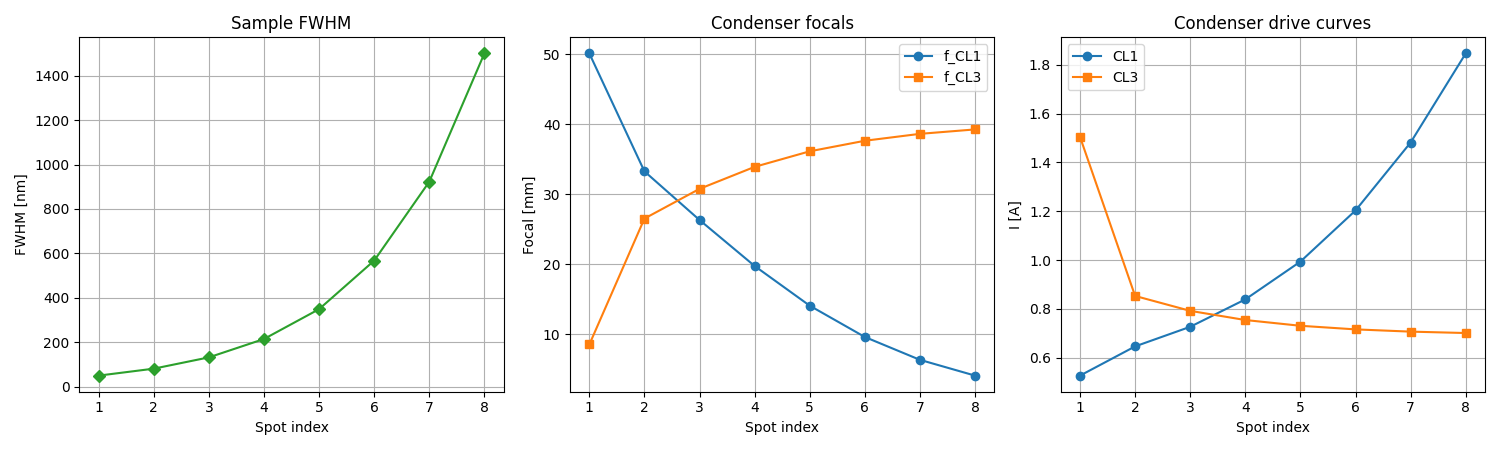

Updated [modes.illumination.parallel] in: microscope.toml
  Spot 1: FWHM = 50 nm, CL1 = 0.5263 A, CL3 = 1.5044 A
  Spot 2: FWHM = 81 nm, CL1 = 0.6461 A, CL3 = 0.8527 A
  Spot 3: FWHM = 132 nm, CL1 = 0.7264 A, CL3 = 0.7917 A
  Spot 4: FWHM = 215 nm, CL1 = 0.8387 A, CL3 = 0.7541 A
  Spot 5: FWHM = 349 nm, CL1 = 0.9935 A, CL3 = 0.7305 A
  Spot 6: FWHM = 568 nm, CL1 = 1.2030 A, CL3 = 0.7158 A
  Spot 7: FWHM = 923 nm, CL1 = 1.4815 A, CL3 = 0.7065 A
  Spot 8: FWHM = 1500 nm, CL1 = 1.8465 A, CL3 = 0.7008 A


In [39]:
# ── Condenser design curves plots ──

spot_idx = np.array([r['spot']    for r in results], dtype=float)
fwhm_nm  = np.array([r['fwhm_nm'] for r in results], dtype=float)
f_cl1_mm = np.array([r['f_CL1']   for r in results]) * 1e3
f_cl3_mm = np.array([r['f_CL3']   for r in results]) * 1e3
i_cl1_a  = np.array([r['I_CL1']   for r in results])
i_cl3_a  = np.array([r['I_CL3']   for r in results])

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

axs[0].plot(spot_idx, fwhm_nm, 'D-', color='tab:green')
axs[0].set(title='Sample FWHM', xlabel='Spot index', ylabel='FWHM [nm]')

axs[1].plot(spot_idx, f_cl1_mm, 'o-', label='f_CL1')
axs[1].plot(spot_idx, f_cl3_mm, 's-', label='f_CL3')
axs[1].set(title='Condenser focals', xlabel='Spot index', ylabel='Focal [mm]')
axs[1].legend()

axs[2].plot(spot_idx, i_cl1_a, 'o-', label='CL1')
axs[2].plot(spot_idx, i_cl3_a, 's-', label='CL3')
axs[2].set(title='Condenser drive curves', xlabel='Spot index', ylabel='I [A]')
axs[2].legend()

fig.tight_layout()
plt.show()

# ── Write to microscope.toml using tomlkit ──

doc = tomlkit.parse(toml_path.read_text())
doc['modes']['illumination']['parallel']['values'] = [
    [float(r['spot']), float(r['I_CL1']), float(r['I_CL3']), 1.0]
    for r in results
]
toml_path.write_text(tomlkit.dumps(doc))

# Verify round-trip
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
with open(toml_path, 'rb') as f:
    tomllib.load(f)

print(f'Updated [modes.illumination.parallel] in: {toml_path}')
for r in results:
    print(f"  Spot {r['spot']}: FWHM = {r['fwhm_nm']:.0f} nm, "
          f"CL1 = {r['I_CL1']:.4f} A, CL3 = {r['I_CL3']:.4f} A")
